# M1 Learning Rate Experiments

This notebook runs the 10 learning-rate presets for Member 1, generates comparison plots, identifies the best learning rate, records a gameplay video, and packages all outputs into a single zip.

Run this on a Colab GPU runtime or locally after installing the repo requirements.

In [1]:
import os

REPO_URL = 'https://github.com/kelvintawe12/Freeway-DQN_formative3.git'
REPO_DIR = REPO_URL.rstrip('/').split('/')[-1].removesuffix('.git')

# If running on Colab, clone the repo and install dependencies.
# If running locally, just ensure we are at the project root.
if os.getcwd() == '/content':
    if not os.path.isdir(REPO_DIR):
        !git clone $REPO_URL
    %cd /content/{REPO_DIR}
    !pip install -q -r requirements.txt
else:
    if os.getcwd().endswith('notebooks'):
        os.chdir('..')
    if not os.path.isfile('requirements.txt'):
        print('Warning: requirements.txt not found. Make sure you are in the repo root.')


Cloning into 'Freeway-DQN_formative3'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 118 (delta 0), reused 2 (delta 0), pack-reused 114 (from 1)
Receiving objects: 100% (118/118), 164.74 MiB | 28.26 MiB/s, done.
Resolving deltas: 100% (48/48), done.
Updating files: 100% (25/25), done.
/content/Freeway-DQN_formative3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 119.8 MB/s eta 0:00:00


In [2]:
import os, glob, zipfile
import pandas as pd
import matplotlib.pyplot as plt
from config import PRESETS, MODELS_DIR, PLOTS_DIR, VIDEOS_DIR, EXPERIMENT_LOG_CSV

M1_PRESETS = [k for k in sorted(PRESETS) if k.startswith('m1_')]
SWEEP_TIMESTEPS = 150_000
FORCE_RERUN = False   # Set to True to re-train even if a model zip already exists

print(f'Found {len(M1_PRESETS)} M1 presets:')
for p in M1_PRESETS:
    print(' ', p)

Found 10 M1 presets:
  m1_lr_01_tiny
  m1_lr_02_verylow
  m1_lr_03_low
  m1_lr_04_baseline
  m1_lr_05_modhigh
  m1_lr_06_high
  m1_lr_07_veryhigh
  m1_lr_08_extreme
  m1_lr_09_extreme2
  m1_lr_10_lowfixed


In [4]:
# Train each M1 preset unless a model zip already exists and FORCE_RERUN is False.
for preset in M1_PRESETS:
    model_path = f'models/{preset}.zip'
    if os.path.exists(model_path) and not FORCE_RERUN:
        print(f'{preset}: model exists, skipping training.')
        continue
    print(f'\n=== Training {preset} ===')
    !python3 train.py --preset {preset} --total-timesteps {SWEEP_TIMESTEPS} --notes "M1 learning rate sweep"


Streaming output truncated to the last 5000 lines.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.05e+03 |
|    ep_rew_mean      | 19.9     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 244      |
|    fps              | 159      |
|    time_elapsed     | 777      |
|    total_timesteps  | 124156   |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 0.0441   |
|    n_updates        | 7134     |
----------------------------------
Eval num_timesteps=125000, episode_reward=22.20 +/- 2.96
Episode length: 2048.00 +/- 0.00
----------------------------------
| eval/               |          |
|    mean_ep_length   | 2.05e+03 |
|    mean_reward      | 22.2     |
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    total_timesteps  | 125000   |
| train/              |          |
|    learning_rate 

In [5]:
# Load the experiment log and keep only the latest M1 rows.
df = pd.read_csv(EXPERIMENT_LOG_CSV)
m1_df = df[df['run_id'].str.startswith('m1_')].copy()
m1_df = m1_df.drop_duplicates(subset='run_id', keep='last')
m1_df = m1_df.sort_values('learning_rate')
m1_df


,run_id,member,policy,env_id,n_envs,n_stack,seed,total_timesteps,learning_rate,gamma,...,std_reward,final_mean_reward,final_std_reward,stochastic_mean_reward,stochastic_std_reward,steps_to_threshold,auc_reward,late_reward_std,wall_clock_seconds,notes
23,m1_lr_01_tiny,member1,CnnPolicy,ALE/Freeway-v5,4,4,42,150000,0.000001,0.99,...,2.766,21.7,1.345,21.3,2.100,25000.0,22.333,0.196,943.9,M1 learning rate sweep
24,m1_lr_02_verylow,member1,CnnPolicy,ALE/Freeway-v5,4,4,42,150000,0.000010,0.99,...,2.492,0.1,0.300,21.1,2.548,25000.0,13.400,10.539,947.8,M1 learning rate sweep
32,m1_lr_10_lowfixed,member1,CnnPolicy,ALE/Freeway-v5,4,4,42,150000,0.000030,0.99,...,2.759,19.7,1.269,20.5,1.204,25000.0,14.367,10.174,973.3,M1 learning rate sweep
25,m1_lr_03_low,member1,CnnPolicy,ALE/Freeway-v5,4,4,42,150000,0.000050,0.99,...,3.033,20.7,1.100,20.7,1.616,25000.0,17.617,6.073,943.1,M1 learning rate sweep
26,m1_lr_04_baseline,member1,CnnPolicy,ALE/Freeway-v5,4,4,42,150000,0.000100,0.99,...,2.766,21.8,1.536,21.3,2.100,25000.0,21.067,1.757,966.8,M1 learning rate sweep
27,m1_lr_05_modhigh,member1,CnnPolicy,ALE/Freeway-v5,4,4,42,150000,0.000300,0.99,...,2.766,21.7,1.345,21.3,2.100,25000.0,22.333,0.196,975.7,M1 learning rate sweep
28,m1_lr_06_high,member1,CnnPolicy,ALE/Freeway-v5,4,4,42,150000,0.000500,0.99,...,2.766,21.7,1.345,21.3,2.100,25000.0,22.333,0.196,973.5,M1 learning rate sweep
29,m1_lr_07_veryhigh,member1,CnnPolicy,ALE/Freeway-v5,4,4,42,150000,0.001000,0.99,...,2.766,21.7,1.345,21.3,2.100,25000.0,22.333,0.196,971.9,M1 learning rate sweep
30,m1_lr_08_extreme,member1,CnnPolicy,ALE/Freeway-v5,4,4,42,150000,0.003000,0.99,...,2.766,21.7,1.345,21.3,2.100,25000.0,22.333,0.196,964.8,M1 learning rate sweep
31,m1_lr_09_extreme2,member1,CnnPolicy,ALE/Freeway-v5,4,4,42,150000,0.010000,0.99,...,2.766,21.7,1.345,21.3,2.100,25000.0,22.333,0.196,970.9,M1 learning rate sweep


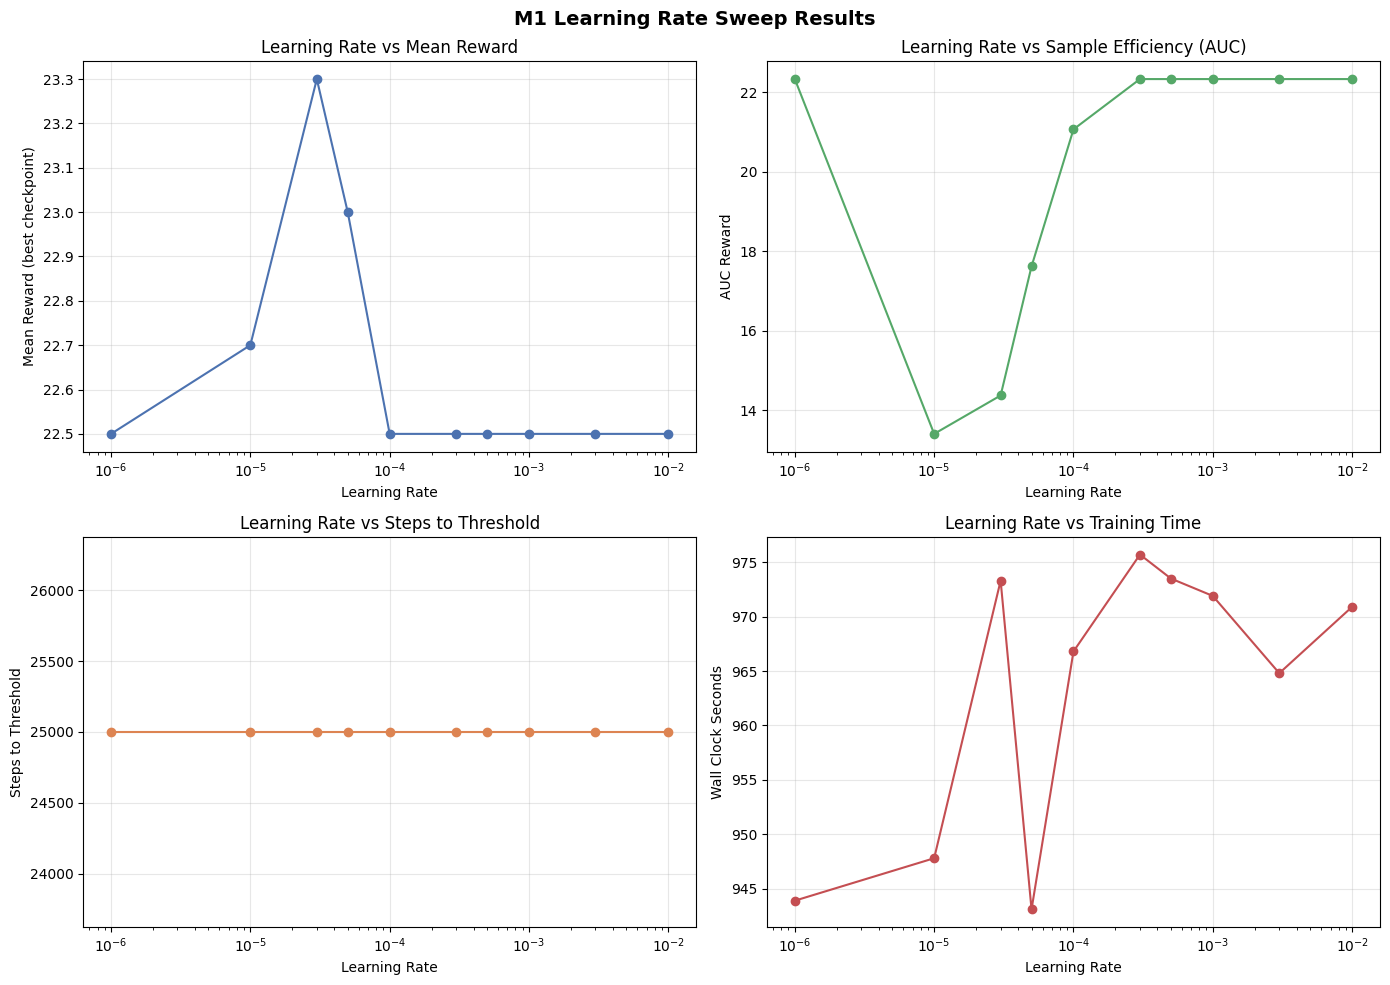

Plot saved to plots/m1_lr_comparison.png


In [6]:
# Plot learning rate against the metrics that matter for this sweep.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(m1_df['learning_rate'], m1_df['mean_reward'], marker='o', color='#4C72B0')
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel('Learning Rate')
axes[0, 0].set_ylabel('Mean Reward (best checkpoint)')
axes[0, 0].set_title('Learning Rate vs Mean Reward')
axes[0, 0].grid(True, alpha=0.3)

if m1_df['auc_reward'].notna().any():
    axes[0, 1].plot(m1_df['learning_rate'], m1_df['auc_reward'], marker='o', color='#55A868')
    axes[0, 1].set_xscale('log')
    axes[0, 1].set_xlabel('Learning Rate')
    axes[0, 1].set_ylabel('AUC Reward')
    axes[0, 1].set_title('Learning Rate vs Sample Efficiency (AUC)')
    axes[0, 1].grid(True, alpha=0.3)

if m1_df['steps_to_threshold'].notna().any():
    axes[1, 0].plot(m1_df['learning_rate'], m1_df['steps_to_threshold'], marker='o', color='#DD8452')
    axes[1, 0].set_xscale('log')
    axes[1, 0].set_xlabel('Learning Rate')
    axes[1, 0].set_ylabel('Steps to Threshold')
    axes[1, 0].set_title('Learning Rate vs Steps to Threshold')
    axes[1, 0].grid(True, alpha=0.3)

if m1_df['wall_clock_seconds'].notna().any():
    axes[1, 1].plot(m1_df['learning_rate'], m1_df['wall_clock_seconds'], marker='o', color='#C44E52')
    axes[1, 1].set_xscale('log')
    axes[1, 1].set_xlabel('Learning Rate')
    axes[1, 1].set_ylabel('Wall Clock Seconds')
    axes[1, 1].set_title('Learning Rate vs Training Time')
    axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('M1 Learning Rate Sweep Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/m1_lr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to plots/m1_lr_comparison.png')


In [7]:
# Select the best learning rate. Tie-breaker order: AUC > mean_reward > steps_to_threshold.
best = m1_df.sort_values(
    by=['auc_reward', 'mean_reward', 'steps_to_threshold'],
    ascending=[False, False, True]
).iloc[0]

print('Best M1 learning rate configuration:')
print(f"  Run ID: {best['run_id']}")
print(f"  Learning Rate: {best['learning_rate']}")
print(f"  Mean Reward: {best['mean_reward']}")
print(f"  AUC Reward: {best['auc_reward']}")
print(f"  Steps to Threshold: {best['steps_to_threshold']}")
print(f"  Wall Clock: {best['wall_clock_seconds']}s")


Best M1 learning rate configuration:
  Run ID: m1_lr_01_tiny
  Learning Rate: 1e-06
  Mean Reward: 22.5
  AUC Reward: 22.333
  Steps to Threshold: 25000.0
  Wall Clock: 943.9s


In [8]:
# Record a gameplay video with the best learning rate model.
best_model_path = f"models/{best['run_id']}.zip"
!python3 play.py --model {best_model_path} --record --episodes 3 --video-name m1_lr_best


2026-07-14 18:43:03.618327: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[Powered by Stella]
Wrapping the env in a VecTransposeImage.
Episode 1: reward=21.0
Episode 2: reward=19.0
Episode 3: reward=20.0
Recorded 3 episodes to /content/Freeway-DQN_formative3/videos
Mean reward across recorded episodes: 20.00
/usr/local/lib/python

In [9]:
from IPython.display import Video, display
import glob, os

# Find the video recorded by play.py and display it inline in the notebook.
# play.py names the file with a step-range suffix, so we glob for m1_lr_best*.mp4.
root = os.environ.get('FREEWAY_OUTPUT_ROOT', '.')
video_files = sorted(glob.glob(os.path.join(root, 'videos', 'm1_lr_best*.mp4')))

if video_files:
    display(Video(video_files[-1], embed=True, width=480, height=360))
else:
    print('No video found. Run the video-recording cell first.')

In [10]:
# Package all outputs into one zip for easy download.
root = os.environ.get('FREEWAY_OUTPUT_ROOT', '.')
zip_path = os.path.join(root, 'm1_results.zip')

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for folder in ['models', 'logs', 'plots', 'videos', 'experiments']:
        full_folder = os.path.join(root, folder)
        if not os.path.isdir(full_folder):
            continue
        for dirpath, dirnames, filenames in os.walk(full_folder):
            for filename in filenames:
                filepath = os.path.join(dirpath, filename)
                arcname = os.path.relpath(filepath, root)
                zf.write(filepath, arcname)
print(f'Zipped outputs to {zip_path}')


Zipped outputs to ./m1_results.zip
